# Name-Change-Effect — a quantitative teardown 🔬
### Abnormal-return event windows on a rebrand table · pop/fade legs vs zero · a Welch *t* + placebo randomization null · the costed believers' trade · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pop_then_dump%3F: Busted](https://img.shields.io/badge/Pop_then_dump%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **two-legged event-study hypothesis** — a positive **pop** right after the rename and a negative **fade** (the give-back) after that — and confront both with the **sample size** and with **survivorship**. The decisive objects are a cross-section of ~21 abnormal-return events and a placebo null sized to that count.

> ⚠️ **Data + survivorship note.** The rebrand table is hardcoded and transparent (~25 real renames across `.com`/`blockchain`/`AI`); the priced tape is **survivor-biased** — the loudest give-backs (Long Blockchain, KodakCoin) **delisted** and leave no series, biasing the fade *up* (named on the Signal axis). Real data: yfinance daily adjusted closes, 1995→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from name_change_effect import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real rebrand-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 25, 'n_delisted': 8, 'n_priced': 21, 'pop': (1.24, 52, 0.51, 0.496), 'fade': (16.22, 52, 1.16, 0.089), 'waves': [('dot-com', 7, -1.31, -3.09), ('blockchain', 6, 1.93, 61.95), ('AI', 8, 2.96, -1.18)], 'robust': [('3/40', 21, -1.48, -0.46, 16.19, 1.32), ('5/60', 21, 1.24, 0.51, 16.22, 1.16), ('10/120', 21, 1.09, 0.29, 51.68, 1.36)], 'cost': {'gross_combo': -14.98, 'net_combo': -16.18, 'gross_pop': 1.24, 'gross_fade': 16.22}, 'syn': [(0.0, 25, 2.22, 1.52, 5.64, 1.19), (0.4, 25, 52.5, 24.05, -29.19, -9.21)]}


real rebrand-tape cache present: True | events priced: 21


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | pop **+1.2%** (Welch **t = 0.51**, placebo **p = 0.50**); fade **+16.2%** (**t = 1.16**) — *positive*, the wrong sign for a give-back. Literature pop + insignificant, sign-wrong tape ⇒ WEAK. |
| **Tradability** | `MIRAGE` | buy-pop/short-fade = **-15.0% gross**, **-16.2% net** of 4 small-cap crossings. The short leg bleeds on a fade that doesn't come. |
| **Pop then dump?** | `BUSTED` | selection-on-anecdotes: the give-backs (Long Blockchain, KodakCoin) **delisted**; the survivor fade is **+16%**. |

> 💡 In plain words: the legend fuses a real-in-1999 *attention pop* with a *symmetric give-back* that, on the names we can still price, simply isn't there — and a couple-dozen events can't certify the faint pop that remains.

## 1 · The claim, steelmanned

Let $r^{i}_{[a,b]}$ be stock $i$'s cumulative **abnormal** return (in excess of SPY) over trading-day offsets $[a,b]$ relative to its rename date (entry lagged one day). Define a **pop** leg $P_i = r^{i}_{[+1,+5]}$ and a **fade** leg $F_i = r^{i}_{[+6,+65]}$.

- **H₁ (the pop).** $\mathbb{E}[P_i] > 0$ — the rename earns an abnormal pop (Cooper-Dimitrov-Rau found ~+74% for dot-com renames in 1998–99).
- **H₂ (the give-back).** $\mathbb{E}[F_i] < 0$ — the pop is *given back* afterward.
- **H₃ (deployable).** $\mathbb{E}[P_i] - \mathbb{E}[F_i]$, net of costs on a long-pop / short-fade book, is positive and harvestable.

We find **H₁ not supported** ($P$ small, $t<1$, inside the placebo cloud), **H₂ rejected with the wrong sign** ($F>0$ on survivors), **H₃ rejected** (the book is gross-negative). The legend is true only where it's a 1999 textbook result, and false where it would pay.

## 2 · So what? — what rides on each answer

The teardown is two one-sample tests on small cross-sections, judged by their **standard error** and by **survivorship**:

$$t_{\text{leg}} = \frac{\bar X}{s_X/\sqrt{k}},\qquad X\in\{P, F\},\ k\approx 21.$$

With $k\approx 21$ and small-cap volatility, $s_X/\sqrt{k}$ is large — a few-percent mean drowns in its own SE. Worse, the sample is **conditioned on survival**: the firms whose fade was most negative (a −100% bankruptcy) **left the tape**, so $\bar F$ is biased **upward** — *toward* refuting H₂ only because the give-backs deleted themselves. The honest instrument for both is a **randomization (placebo) test**: resample $k$ random non-event windows on the same tickers and ask how often chance matches each leg. That, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Rebrand table.** ~25 documented theme-chasing renames (`.com` 1998–2001, `blockchain` 2017–2020, `AI` 2020–2024), hardcoded & transparent; **8** famous give-backs are listed as **DELISTED** (no series) for the survivorship caveat. **21** priced.
- **Abnormal returns.** Daily log return in excess of SPY; pop $=[+1,+5]$, fade $=[+6,+65]$ trading days, **1-day entry lag** (act the day after the headline).
- **Null #1 (Welch t).** Each leg's cross-sectional mean vs zero.
- **Null #2 (placebo).** 20,000 draws of $k$ random non-event windows on the same tickers; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Costs.** A long-pop / short-fade book pays a one-way small-cap charge on **four** crossings per event.
- **Positive control.** Deterministic event windows with a **planted** pop+give-back of size `edge`: the inference must recover a large edge **and** must NOT manufacture significance when `edge = 0`.

## 4 · The teardown

### 4a · The two legs — a faint pop, a wrong-signed fade

Mean abnormal return per leg with $\pm$ standard error, against zero (dashed). The pop is small and inside its SE; the fade is *positive* — the give-back is absent.

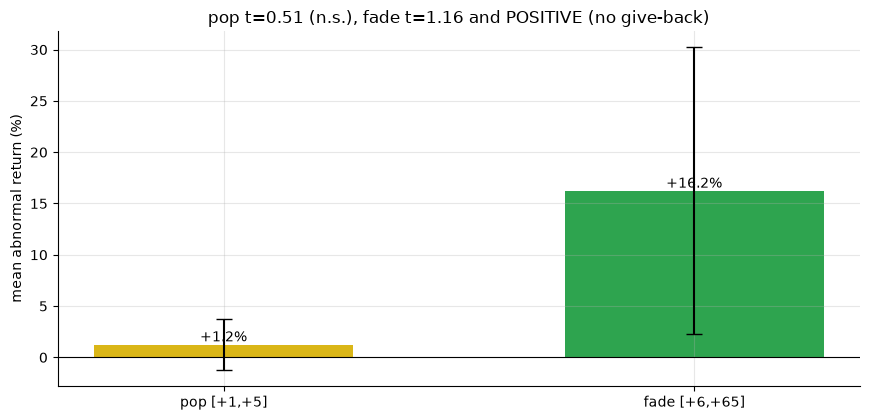

pop +1.24% (t=0.51)   fade +16.22% (t=1.16) — H2 wants fade<0; it is >0


In [2]:
if HAVE_REAL:
    P = EV['pop'].values; F = EV['fade'].values
    pm, fm = P.mean()*100, F.mean()*100
    pse, fse = P.std(ddof=1)/np.sqrt(len(P))*100, F.std(ddof=1)/np.sqrt(len(F))*100
    pt, ft = st.welch_t(P), st.welch_t(F)
else:
    pm, fm, pt, ft = R['pop'][0], R['fade'][0], R['pop'][2], R['fade'][2]
    pse, fse = pm/max(pt,1e-9), fm/max(ft,1e-9)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['pop [+1,+5]','fade [+6,+65]'], [pm, fm], yerr=[pse, fse], capsize=6,
       color=[AMBER, GREEN], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean abnormal return (%)')
ax.set_title(f'pop t={pt:.2f} (n.s.), fade t={ft:.2f} and POSITIVE (no give-back)')
for i,v in enumerate([pm,fm]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'pop {pm:+.2f}% (t={pt:.2f})   fade {fm:+.2f}% (t={ft:.2f}) — H2 wants fade<0; it is >0')

> 💡 In plain words: the pop is **+1.2%** at **t = 0.51** (not significant); the fade is **+16%** at **t = 1.16** — *positive*, so H₂ (the give-back) is rejected with the **wrong sign**, and survivorship only pushes it *more* positive.

### 4b · The decisive test — a placebo null sized to the event count

Draw 21 random non-event windows 20,000 times; the histogram is the null for the mean pop. The real pop is the green line; the *p*-value is the two-sided tail mass.

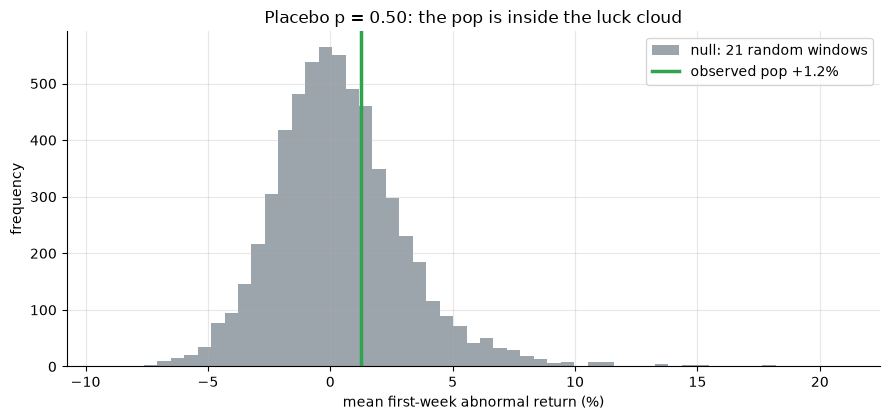

P[|random 21-window mean| >= |pop|] = 0.504  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='pop', observed=EV['pop'].mean(), n_draws=6000)
    obs = pl['obs']*100; pval = pl['p_value']
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>80]; rng=np.random.default_rng(389)
    draws=[]
    for _ in range(6000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-7); vals.append(np.expm1(s.iloc[p0:p0+5].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['pop'][0]; pval=R['pop'][3]; rng=np.random.default_rng(389); draws=rng.normal(0,2.0,6000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_priced"]} random windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed pop {obs:+.1f}%')
ax.set_xlabel('mean first-week abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the pop is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_priced"]}-window mean| >= |pop|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **50%** of random 21-window draws match or beat the pop in magnitude. A real effect would push the green line into the tail; instead it sits mid-cloud. H₁ is **not supported** — the pop is what a couple-dozen random press releases look like.

### 4c · By wave + robustness — the give-back is nowhere

Split by wave and shift the windows. The fade is **positive in every wave and at every horizon** (the blockchain survivors — RIOT/BTBT/MSTR — rode the 2020–21 bull *up*), and the pop *t* never clears 1.

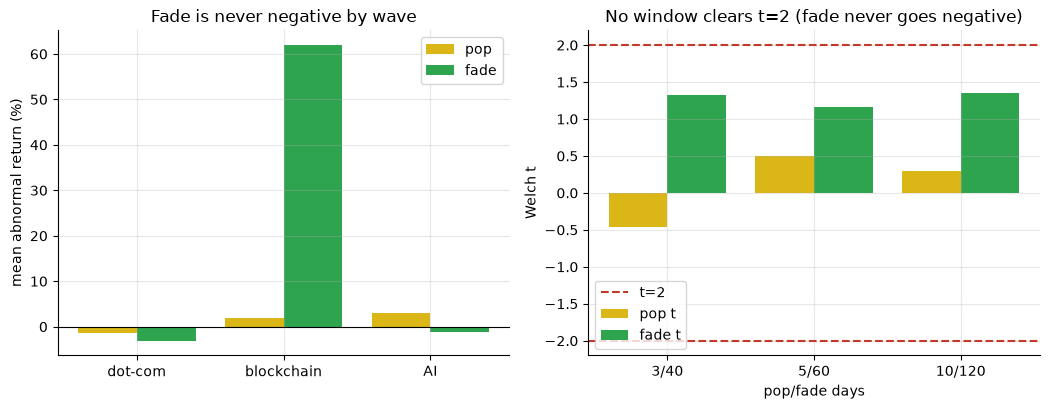

waves: [('dot-com', np.float64(-1.3), np.float64(-3.1)), ('blockchain', np.float64(1.9), np.float64(61.9)), ('AI', np.float64(3.0), np.float64(-1.2))]


In [4]:
waves = R['waves']
if HAVE_REAL:
    waves = []
    for w in ['dotcom','blockchain','ai']:
        sub = EV[EV['wave']==w]
        nm = {'dotcom':'dot-com','blockchain':'blockchain','ai':'AI'}[w]
        waves.append((nm, len(sub), sub['pop'].mean()*100, sub['fade'].mean()*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
names=[w[0] for w in waves]; wpop=[w[2] for w in waves]; wfade=[w[3] for w in waves]; xx=np.arange(len(names))
a1.bar(xx-.2, wpop, .4, color=AMBER, label='pop'); a1.bar(xx+.2, wfade, .4, color=GREEN, label='fade')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(xx); a1.set_xticklabels(names)
a1.set_ylabel('mean abnormal return (%)'); a1.set_title('Fade is never negative by wave'); a1.legend()
if HAVE_REAL:
    rob=[]
    for pd_,fd_ in [(3,40),(5,60),(10,120)]:
        e2=st.collect_events(B,pop=pd_,fade=fd_); s2=st.summarize(e2,B,pop=pd_,fade=fd_,placebo=False)
        rob.append((f'{pd_}/{fd_}', s2['n'], s2['pop']['mean']*100, s2['pop']['t'], s2['fade']['mean']*100, s2['fade']['t']))
else:
    rob = R['robust']
labs=[r[0] for r in rob]; pts=[r[3] for r in rob]; fts=[r[5] for r in rob]; xx2=np.arange(len(labs))
a2.bar(xx2-.2, pts, .4, color=AMBER, label='pop t'); a2.bar(xx2+.2, fts, .4, color=GREEN, label='fade t')
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(xx2); a2.set_xticklabels(labs); a2.set_ylabel('Welch t'); a2.set_xlabel('pop/fade days')
a2.set_title('No window clears t=2 (fade never goes negative)'); a2.legend()
plt.tight_layout(); plt.show()
print('waves:', [(w[0], round(w[2],1), round(w[3],1)) for w in waves])

> 💡 In plain words: the dot-com survivors barely moved (the spectacular renames delisted); the blockchain survivors **mooned** (+62% fade — the opposite of a give-back); the AI survivors went roughly flat. No wave gives it back, and no window makes the pop significant. The result is flat in every choice that could have rescued it.

### 4d · Faithful-engine & power control — we know the truth here

Deterministic event windows with a **planted** pop+give-back of size `edge`: with **`edge=0`** the inference must stay flat (a couple-dozen noisy events can't fake significance); with a **+40%** planted pop-then-full-give-back it must light up **both** legs. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large effects.

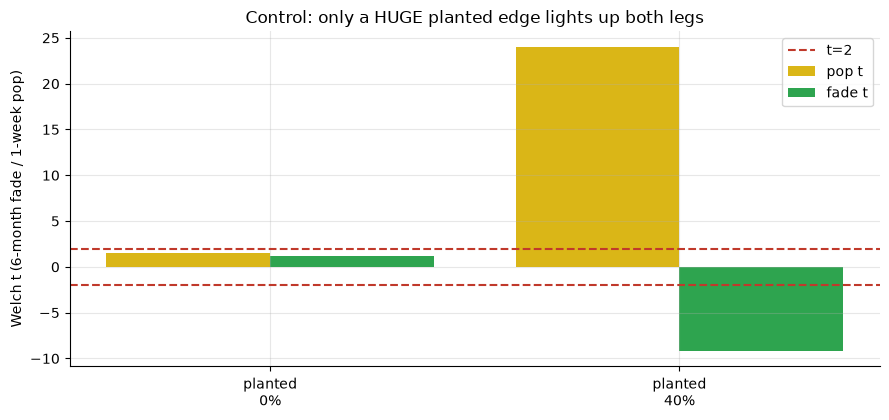

planted   0%: n=25 pop=+2.2%(t=+1.52) fade=+5.6%(t=+1.19)
planted  40%: n=25 pop=+52.5%(t=+24.05) fade=-29.2%(t=-9.21)


In [5]:
res = []
for edge in (0.0, 0.40):
    syn = data.synthetic_rebrands(n_events=25, edge=edge, seed=389)
    ev = st.collect_events(syn, pop=5, fade=60); s = st.summarize(ev, syn, pop=5, fade=60, placebo=False)
    res.append((edge, s['n'], s['pop']['mean']*100, s['pop']['t'], s['fade']['mean']*100, s['fade']['t']))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=[f'planted\n{int(e*100)}%' for e,*_ in res]; xx=np.arange(len(labels))
pts=[r[3] for r in res]; fts=[r[5] for r in res]
ax.bar(xx-.2, pts, .4, color=AMBER, label='pop t'); ax.bar(xx+.2, fts, .4, color=GREEN, label='fade t')
ax.axhline(2, ls='--', c=RED, label='t=2'); ax.axhline(-2, ls='--', c=RED)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t (6-month fade / 1-week pop)')
ax.set_title('Control: only a HUGE planted edge lights up both legs'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,pm,pt,fm,ft in res: print(f'planted {int(e*100):>3}%: n={k} pop={pm:+.1f}%(t={pt:+.2f}) fade={fm:+.1f}%(t={ft:+.2f})')

> 💡 In plain words: with **no** planted edge the control's pop *t* is **1.52** and fade *t* is **1.19** (both small — no false positive); only the **+40%** plant reaches pop *t* **24.05** / fade *t* **-9.21**. So the machinery is honest, and the real-tape pop *t* of **0.51** is exactly what an *absent or tiny* effect looks like through a 21-event keyhole.

## 5 · The verdict

- **Signal `WEAK`** — pop **+1.2%** at Welch **t = 0.51** / placebo **p = 0.50**; fade **+16.2%** at **t = 1.16** (positive — wrong sign for a give-back). Literature pop (Cooper-Dimitrov-Rau 2001) + an insignificant, sign-wrong tape ⇒ WEAK, not REAL. **Survivorship** named on this axis: the worst give-backs delisted, biasing the fade *up*.
- **Tradability `MIRAGE`** — buy-pop/short-fade = **-15.0% gross**, **-16.2% net** of 4 small-cap crossings. The short leg bleeds on a give-back that doesn't happen; no NAV-scale edge.
- **Pop then dump? `BUSTED`** — the legend is selection-on-anecdotes (Long Blockchain, KodakCoin **delisted**); across a representative survivor table the pop is a coin-flip and the fade runs **+16%** the wrong way.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* pop have to be for a $k$-event study to detect it at $t=2$? At $k\approx 21$ you'd need a pop several times the one observed; the real signal lives far below the detection floor — and the short leg is negative-carry on top.

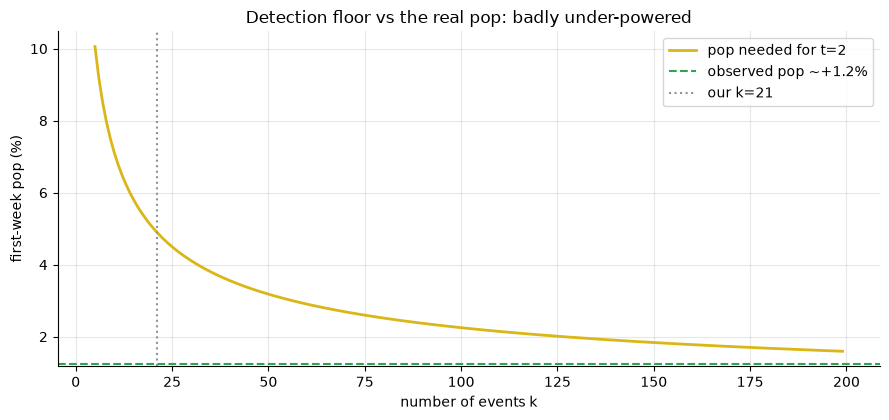

at k=21 you need ~4.9% pop for t=2; observed ~+1.2% -> under-powered


In [6]:
if HAVE_REAL:
    sd = EV['pop'].std(ddof=1); obs = EV['pop'].mean()
else:
    sd = 0.10; obs = R['pop'][0]/100
ks = np.arange(5, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='pop needed for t=2')
ax.axhline(obs*100, c=GREEN, ls='--', label=f'observed pop ~{obs*100:+.1f}%')
ax.axvline(R['n_priced'], c=GREY, ls=':', label=f"our k={R['n_priced']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('first-week pop (%)')
ax.set_title('Detection floor vs the real pop: badly under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_priced'])*100
print(f'at k={R["n_priced"]} you need ~{need:.1f}% pop for t=2; observed ~{obs*100:+.1f}% -> under-powered')

> 💡 In plain words: the amber curve is the **minimum detectable pop**; the green line is what we see. They don't meet until $k$ is many times larger than the rebrand calendar will ever deliver — and even a *real* pop wouldn't pay, because the give-back leg you'd short is **positive** on the survivors. There is no sizing, threshold, or cost assumption that manufactures an edge from ~21 events whose second leg runs the wrong way. The rarity that makes the legend romantic is exactly what makes it untestable and untradable.

## 7 · Going further

- **The adjacent name effect.** [Study 169 — Fluent-Tickers](../169-fluent-tickers/): does a *pronounceable* ticker carry a premium? Same family (a label, not a fundamental), same small-sample / survivorship pathology.
- **The anecdote trap, formalised.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) on how loud cases manufacture spurious 'laws'.
- **Add the corpses.** Reconstruct the delisted rebrands (Long Blockchain, KodakCoin, fatbrain.com) from a survivorship-free CRSP/Norgate feed; the pop may grow, but the 'fade' becomes a −100% bankruptcy — informative about the *story*, not a tradable leg.

*The reproducible core is offline and deterministic; the rebrand table is hardcoded and the priced tape is survivor-biased (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*